##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
!pip install --upgrade keras-cv
!pip install --upgrade keras

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

--- Results for det1.jpg ---


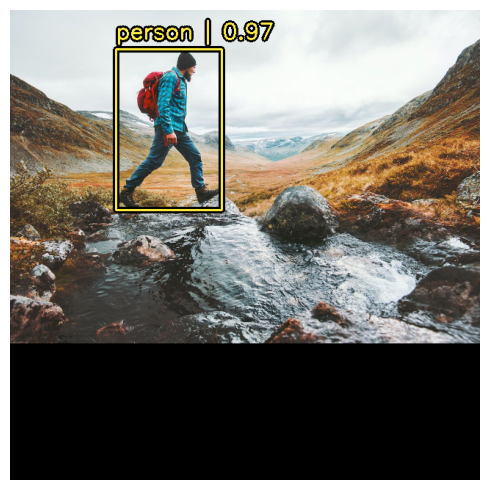

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

--- Results for det2.jpg ---


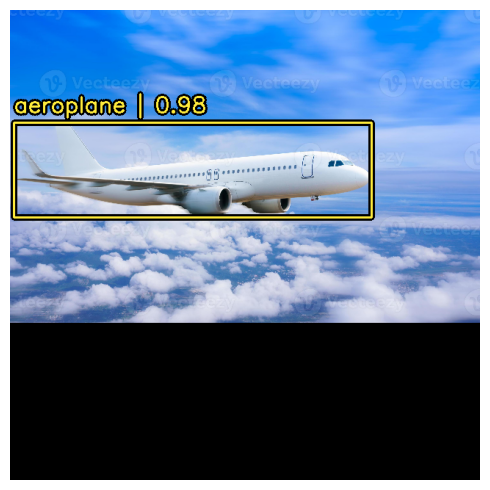

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

--- Results for det3.jpg ---


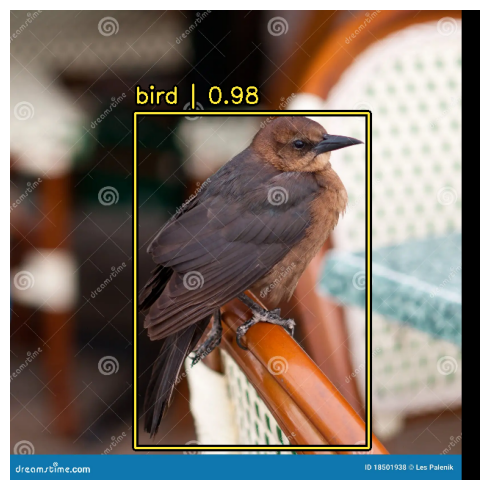

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

--- Results for det4.jpg ---


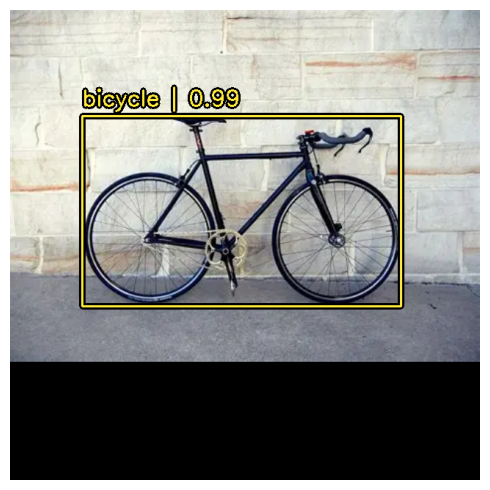

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

--- Results for det5.jpg ---


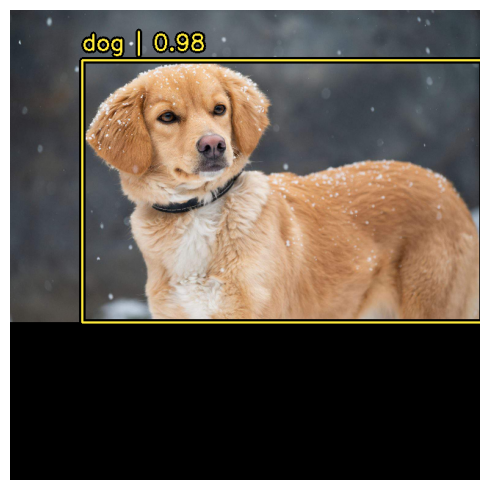

In [8]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import keras_cv
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load the pre-trained YOLOV8 model from KerasCV using the Pascal VOC preset
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

# 2. Load 5 images for different classes and convert it into a NumPy array
image_files = ["det1.jpg", "det2.jpg", "det3.jpg", "det4.jpg", "det5.jpg"]

# 3. Resize the images before inference to match the model’s expected input size
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

# Official Pascal VOC class mapping
class_mapping = {
    0: "aeroplane", 1: "bicycle", 2: "bird", 3: "boat", 4: "bottle",
    5: "bus", 6: "car", 7: "cat", 8: "chair", 9: "cow",
    10: "diningtable", 11: "dog", 12: "horse", 13: "motorbike", 14: "person",
    15: "pottedplant", 16: "sheep", 17: "sofa", 18: "train", 19: "tvmonitor"
}

# 4. Run the YOLOV8 detector on each image to predict bounding boxes
# 5. Visualize the predictions by drawing the bounding boxes and labels
for file in image_files:
    if os.path.exists(file):
        # Step 2: Load
        img = np.array(Image.open(file).convert("RGB"))

        # Step 3: Resize
        img_batch = inference_resizing(np.expand_dims(img, axis=0))

        # Step 4: Run Inference
        y_pred = model.predict(img_batch)

        # Step 5: Visualize
        print(f"\n--- Results for {file} ---")
        keras_cv.visualization.plot_bounding_box_gallery(
            img_batch,
            value_range=(0, 255),
            y_pred=y_pred,
            class_mapping=class_mapping,
            bounding_box_format="xywh",  # This fixes the TypeError
            scale=5,
            rows=1,
            cols=1,
            line_thickness=2
        )
        plt.show()
    else:
        print(f"Error: {file} not found. Please upload it.")

| Image File | Objects Detected | Confidence Score | Correct? | Missed/Incorrect |
| :--- | :--- | :--- | :--- | :--- |
| det1.jpg | person | 0.97 | Yes | None |
| det2.jpg | aeroplane | 0.98 | Yes | None |
| det3.jpg | bird | 0.98 | Yes | None |
| det4.jpg | bicycle | 0.99 | Yes | None |
| det5.jpg | dog | 0.98 | Yes | None |